In [58]:
import os
import matplotlib.pyplot as plt

import numpy as np
from skimage import measure
import pandas as pd
from stardist import export_imagej_rois, random_label_cmap
from tifffile import imread
from typing import Optional
def read_tiff_file(
    file_path: str,
    channels_to_keep: Optional[list[int]] = None,
) -> np.ndarray:
    """
    Read a TIFF file and optionally select specific channels from the image.

    Parameters:
            file_path (str): Path to the TIFF image file.
            channels_to_keep (list): List of channel indices to keep. If empty or None, all channels are kept.

    Returns:
            np.ndarray: The image data as a NumPy array. The number of dimensions may vary depending on the input and selected channels.

    Raises:
            ValueError: If the image file cannot be read.
    """
    try:
        image = imread(file_path)
    except Exception as e:
        raise ValueError(f"Error while reading image file {file_path} : {e}")

    # If no channels are specified, return the image as is.
    if image.ndim == 2 or not channels_to_keep:
        return image

    if image.ndim == 3:
        return image[channels_to_keep, ...].squeeze()  # type: ignore
    else:
        return image[:, channels_to_keep, ...].squeeze()  # type: ignore

cmap = random_label_cmap()
        
raw_dir = "/mnt/towbin.data/shared/spsalmon/stardist_database/443_60x_emr1_classification_dataset/raw"
mask_dir =  "/mnt/towbin.data/shared/spsalmon/stardist_database/443_60x_emr1_classification_dataset/mask"

raw_paths = sorted([os.path.join(raw_dir, f) for f in os.listdir(raw_dir)])
mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])

# remove raw images that do not have a corresponding mask
raw_paths = [p for p in raw_paths if os.path.basename(p) in [os.path.basename(m) for m in mask_paths]]
mask_paths = [p for p in mask_paths if os.path.basename(p) in [os.path.basename(r) for r in raw_paths]]

print(len(raw_paths), len(mask_paths))

497 497


/mnt/towbin.data/shared/spsalmon/stardist_database/443_60x_emr1_classification_dataset/raw/Time00015_Point0010_ChannelGFP,mCherry_Seq1180.ome.tiff
/mnt/towbin.data/shared/spsalmon/stardist_database/443_60x_emr1_classification_dataset/mask/Time00015_Point0010_ChannelGFP,mCherry_Seq1180.ome.tiff
[ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 24]


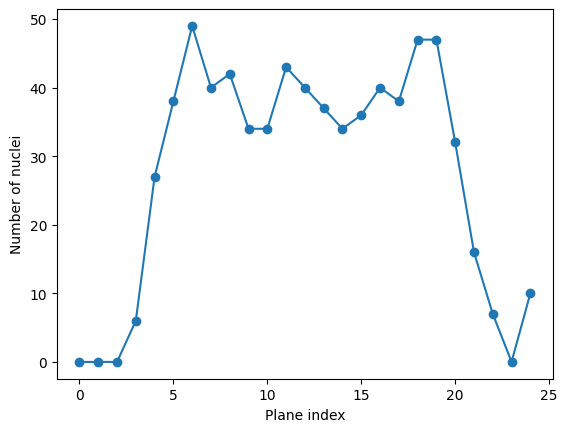

In [59]:
idx = np.random.randint(len(raw_paths))

print(raw_paths[idx])
print(mask_paths[idx])

raw = read_tiff_file(raw_paths[idx])
mask = read_tiff_file(mask_paths[idx])

# count the number of objects in the mask
nuclei_counts = np.array([np.max(plane) for plane in mask])
planes = np.arange(len(nuclei_counts))[nuclei_counts >= 5]
# planes = np.arange(len(nuclei_counts))
print(planes)

plt.plot(nuclei_counts, marker='o')
plt.xlabel("Plane index")
plt.ylabel("Number of nuclei")
plt.show()

     plane_id  label  class  perimeter
0           3      1      1  47.455844
1           3      2      1  60.526912
2           3      3      1  47.698485
3           3      4      1  47.213203
4           3      5      1  46.384776
..        ...    ...    ...        ...
692        24      6      0  29.556349
693        24      7      0  29.313708
694        24      8      1  27.313708
695        24      9      0  28.727922
696        24     10      0  48.627417

[697 rows x 4 columns]
Best plane: 6 with 39 positive nuclei
Densest plane: 19 with 43 nuclei


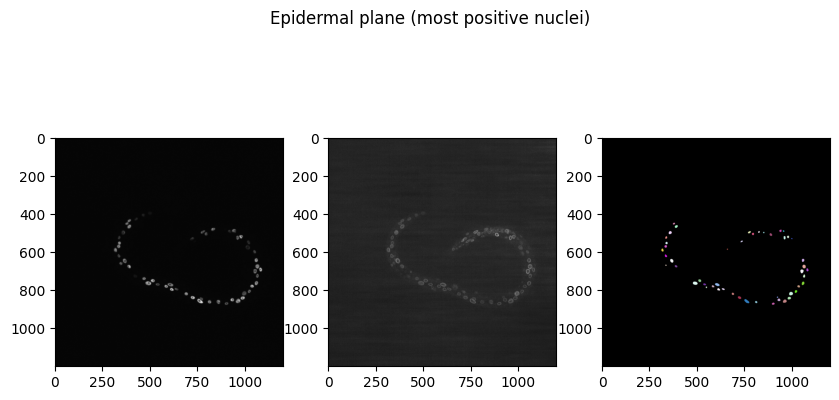

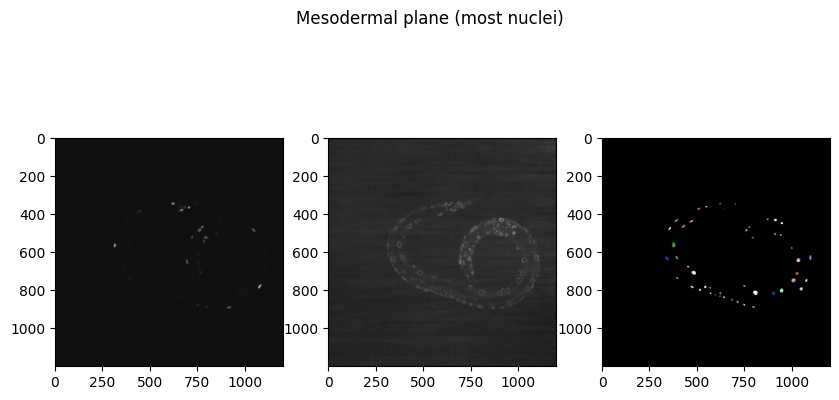

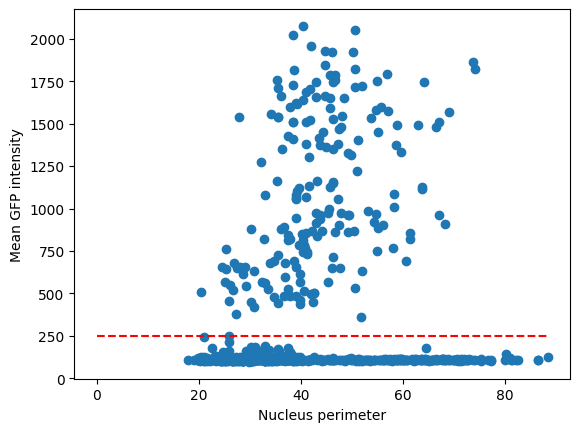

In [60]:

def automatic_nuclei_classification(raw, mask, planes, gfp_channel=0):
    selected_raw = raw[planes]
    selected_mask = mask[planes]

    raw_gfp = selected_raw[:, gfp_channel]

    res = []
    all_plane_classes = []
    for plane_id, raw_plane, mask_plane in zip(planes, raw_gfp, selected_mask):
        props = measure.regionprops(mask_plane.astype(int), intensity_image=raw_plane)
        for i, p in enumerate(props):
            res.append((p.perimeter, p.mean_intensity))

        nuclei_classes = []
        for p in props:
            label = p.label
            if p.mean_intensity > 250:
                nuclei_classes.append({'plane_id': plane_id, 'label': label, 'class': 1, 'perimeter': p.perimeter})  # positive
            else:
                nuclei_classes.append({'plane_id': plane_id, 'label': label, 'class': 0, 'perimeter': p.perimeter})  # negative
        all_plane_classes.extend(nuclei_classes)

    df = pd.DataFrame(all_plane_classes)
    print(df)

    # get the plane with the most positive nuclei
    pos_counts = df[df['class'] == 1].groupby('plane_id').size()
    best_plane = pos_counts.idxmax()
    print(f"Best plane: {best_plane} with {pos_counts.max()} positive nuclei")
    epidermal_plane = raw[best_plane]
    # get the plane with the most negative nuclei, ignoring very small ones
    size_threshold = np.percentile(df['perimeter'], 20)
    total_counts = df[df['class'] == 0 & (df['perimeter'] >= size_threshold)].groupby('plane_id').size()
    densest_plane = total_counts.idxmax()
    print(f"Densest plane: {densest_plane} with {total_counts.max()} nuclei")
    mesodermal_plane = raw[densest_plane]

    # # get the plane with the widest distribution of nuclei perimeters
    # perimeter_std = df.groupby('plane_id')['perimeter'].std()
    # densest_plane = perimeter_std.idxmax()
    # print(f"Densest plane: {densest_plane} with std of perimeter {perimeter_std.max()}")
    # mesodermal_plane = raw[densest_plane]

    fig, axes = plt.subplots(1, 3, figsize=(10, 5))
    axes[0].imshow(epidermal_plane[gfp_channel], cmap='gray')
    axes[1].imshow(epidermal_plane[1], cmap='gray')
    axes[2].imshow(mask[best_plane], cmap=cmap)
    fig.suptitle("Epidermal plane (most positive nuclei)")
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(10, 5))
    axes[0].imshow(mesodermal_plane[gfp_channel], cmap='gray')
    axes[1].imshow(mesodermal_plane[1], cmap='gray')
    axes[2].imshow(mask[densest_plane], cmap=cmap)
    fig.suptitle("Mesodermal plane (most nuclei)")
    plt.show()
        
    plt.scatter(*zip(*res))
    plt.hlines(250, xmin=0, xmax=np.max([r[0] for r in res]), colors='r', linestyles='dashed')
    plt.xlabel("Nucleus perimeter")
    plt.ylabel("Mean GFP intensity")
    plt.show()
    return selected_raw, selected_mask

selected_raw, selected_mask = automatic_nuclei_classification(raw, mask, planes, gfp_channel=0)